In [1]:
import requests
import zipfile
import io
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import hypergeom
import itertools

In [ ]:
zip_url = 'https://epoch.ai/data/gpu_clusters.zip'

# Download and extract the zip file
response = requests.get(zip_url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # List files to find the CSV
    file_list = z.namelist()
    print(f"Files in ZIP: {file_list}")

    # Extract all files to current directory
    z.extractall()

# Load the first CSV found in the zip
csv_files = [f for f in file_list if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(csv_files[0])
    print(f"Successfully loaded: {csv_files[0]}")
    display(df.head())
else:
    print("No CSV file found in the ZIP archive.")

Files in ZIP: ['README.md', 'gpu_clusters.csv']
Successfully loaded: gpu_clusters.csv


,Name,Status,Certainty,Single cluster?,Max OP/s (log),H100 equivalents,Chip type (primary),Chip quantity (primary),Country,Owner,...,Cost Quote,Noteworthy,Decommissioned Date (if applicable),Largest existing cluster when first operational,% of largest cluster when first operational,Source 1,Source 2,Source 3,Source 4,Source 5
0,xAI Colossus Memphis Phase 3,Existing,Confirmed,Yes,20.737034,275795.856497,NVIDIA H100 SXM5 80GB,200000.0,United States of America,xAI,...,NaN,True,NaN,NaN,NaN,https://archive.ph/oHQSA,NaN,NaN,NaN,NaN
1,xAI Colossus Memphis Phase 2,Existing,Likely,Yes,20.597476,200000.000003,NVIDIA H100 SXM5 80GB,150000.0,United States of America,xAI,...,NaN,NaN,NaN,xAI Colossus Memphis Phase 2,1.0,https://archive.ph/z39uN,https://web.archive.org/web/20241217184541/htt...,https://web.archive.org/web/20241217184541/htt...,https://www.youtube.com/watch?v=AUAJ82H12qs&t=...,NaN
2,xAI Colossus Memphis Phase 1,Existing,Confirmed,Yes,20.296446,100000.000001,NVIDIA H100 SXM5 80GB,100000.0,United States of America,xAI,...,NaN,NaN,NaN,xAI Colossus Memphis Phase 1,1.0,https://archive.ph/Bh9Tq,https://web.archive.org/web/20240727065656/htt...,https://archive.ph/z39uN,NaN,NaN
3,Meta 100k,Existing,Likely,Yes,20.296446,100000.000001,NVIDIA H100 SXM5 80GB,100000.0,United States of America,Meta AI,...,NaN,True,NaN,xAI Colossus Memphis Phase 1,1.0,https://archive.ph/85KB1,https://web.archive.org/web/20240901171617/htt...,https://web.archive.org/web/2/https://www.toms...,https://web.archive.org/web/20241228090751/htt...,NaN
4,OpenAI/Microsoft Goodyear Arizona,Existing,Likely,Yes,20.296446,100000.000001,NVIDIA H100 SXM5 80GB,100000.0,United States of America,"Microsoft,OpenAI",...,NaN,NaN,NaN,xAI Colossus Memphis Phase 1,1.0,https://web.archive.org/web/20241006181731/htt...,https://web.archive.org/web/20240609051243/htt...,https://www.youtube.com/watch?v=hobvps-H38o,NaN,NaN


In [3]:
# Filter records where 'Total number of AI chips' is not null or empty
df_filtered = df[df['Total number of AI chips'].notna()]
# Ensure we don't have empty strings if the column was loaded as objects
df_filtered = df_filtered[df_filtered['Total number of AI chips'] != '']

# Further filter to exclude clusters in the U.S. or China
countries_to_exclude = ['United States of America', 'China']
df_filtered = df_filtered[~df_filtered['Country'].isin(countries_to_exclude)]

print(f"Number of records remaining: {len(df_filtered)}")
print(f"Unique countries remaining: {df['Country'].unique()}")
display(df_filtered)

NameError: name 'df' is not defined

In [2]:
def p_detect_cluster_diversion(N: int, n: int, K: int, m: float) -> dict:
    if K == 0 or n == 0:
        return {"p_success": 0.0, "p_failure": 1.0}

    # x is the number of bad records in our sample of size n
    # The probability of picking exactly x bad records follows a hypergeometric distribution
    x_values = np.arange(max(0, n - (N - K)), min(K, n) + 1)
    p_x = hypergeom.pmf(x_values, N, K, n)

    # If we find x bad records, the probability we miss ALL of them is m^x
    # We sum up (prob of getting x bad records) * (prob of missing all x)
    p_failure = np.sum(p_x * (m ** x_values))
    p_success = 1 - p_failure

    return {
        "p_success": p_success,
        "p_failure": p_failure
    }
def expected_value_detected_diversion(N: int, n: int, K: int, m: float) -> dict:
    """
    N = total records
    n = records tested
    K = number of bad records
    m = probability that the test misses a bad record
    """

    p_detect = p_detect_cluster_diversion(N=N, n=n, K=K, m=m)['p_success']
    diverted_chips_identified = p_detect*K

    return {
        "diverted_chips_identified": diverted_chips_identified,
        "p_detect": p_detect
    }

In [ ]:
# print(expected_value_detected_diversion(N=100000, n=1, K=100000, m=0.05))

In [3]:
# Define scenarios to test
cluster_sizes = [8, 10, 100, 1000, 10000, 100000, 200000]
"""
N = total records
n = records tested
K = number of bad records
m = probability that the test misses a bad record
"""
K_vals = [1, 8, 10, 100, 1000, 10000, 100000, 200000]
n_vals = [1, 8, 10, 100, 1000]
m_vals = [0.05]

detection_lookup_table_data = []

for N in cluster_sizes:
    for n in n_vals:
        # Constraint: n cannot be greater than cluster size N
        if n > N:
            continue
        for K in K_vals:
            # Constraint: K (bad records) cannot be greater than cluster size N
            if K > N:
                continue
            for m in m_vals:
                res_physInspc = expected_value_detected_diversion(N, n, K, m)
                res_PLV = expected_value_detected_diversion(N, N, K, m)

                detection_lookup_table_data.append({
                    'Cluster Size (N)': N,
                    'Tests (n)': n,
                    'Bad Records (K)': K,
                    'Share Diverted': K / N,
                    'Chip-level Miss Prob (m)': m,
                    'Physical Inspection - P(Detect)': f"{res_physInspc['p_detect']:.4f}",
                    'Physical Inspection - Diverted Chips Identified': f"{res_physInspc['diverted_chips_identified']:.2f}",
                    'PLV - P(Detect)': f"{res_PLV['p_detect']:.4f}",
                    'PLV - Diverted Chips Identified': f"{res_PLV['diverted_chips_identified']:.2f}"
                })

detection_lookup_table = pd.DataFrame(detection_lookup_table_data)

# Filter out records with Share Diverted below X%
# expected_value_lookup_table = expected_value_lookup_table[expected_value_lookup_table['Share Diverted'] >= 0.5]

In [ ]:
target_chips = 2000000
steps = np.arange(0, 1.1, 0.1)

# 1. Generate base fleet mixes (No change here, this part is efficient enough)
proportions_list = [p for p in itertools.product(steps, repeat=len(cluster_sizes)) if sum(p) == 1.0]

mix_data = []
for i, props in enumerate(proportions_list):
    mix_id = f"ClusterMix{i+1}"
    active = [(n, p) for n, p in zip(cluster_sizes, props) if p > 0]

    valid = True
    current_mix = []
    for n_val, prop in active:
        count = (target_chips * prop) / n_val
        # Check if count is a whole number (i.e., no partial clusters)
        if count == int(count):
            current_mix.append({'Mix ID': mix_id, 'Cluster Size (N)': int(n_val), 'Number of Clusters': int(count)})
        else:
            valid = False
            break
    if valid:
        mix_data.append(current_mix)

print(f"Processing {len(mix_data)} valid mixes into combinatorial scenarios...")

# Pre-process detection_lookup_table for faster access and correct types
# Ensure relevant columns are numeric for calculations
detection_lookup_table['Cluster Size (N)'] = detection_lookup_table['Cluster Size (N)'].astype(int)
detection_lookup_table['Bad Records (K)'] = detection_lookup_table['Bad Records (K)'].astype(int)
detection_lookup_table['Tests (n)'] = detection_lookup_table['Tests (n)'].astype(int)
detection_lookup_table['Chip-level Miss Prob (m)'] = detection_lookup_table['Chip-level Miss Prob (m)'].astype(float)
detection_lookup_table['Physical Inspection - Diverted Chips Identified'] = detection_lookup_table['Physical Inspection - Diverted Chips Identified'].astype(float)
detection_lookup_table['PLV - Diverted Chips Identified'] = detection_lookup_table['PLV - Diverted Chips Identified'].astype(float)

# Create a lookup dictionary for (N, K) -> list of (n, m, phys_identified, plv_identified)
# This will be much faster than merging large dataframes repeatedly
detection_grouped = detection_lookup_table.groupby(['Cluster Size (N)', 'Bad Records (K)']).apply(
    lambda x: list(zip(x['Tests (n)'], x['Chip-level Miss Prob (m)'],
                       x['Physical Inspection - Diverted Chips Identified'],
                       x['PLV - Diverted Chips Identified']))
).to_dict()

# 2. Combinatorial Expansion and Direct Aggregation
# This section replaces the creation of scenario_df and final_scenarios
summary_records = []

for i, mix_components in enumerate(mix_data):
    mix_id = mix_components[0]['Mix ID']
    total_clusters_in_mix = sum(c['Number of Clusters'] for c in mix_components)

    if (i + 1) % 1000 == 0:
        print(f"Expanding mix {i+1}...")

    # For each component in the mix, determine its possible K values
    k_options_per_component = []
    for component in mix_components:
        # Filter K_vals based on current component's Cluster Size (N)
        valid_ks_for_component = [k for k in K_vals if k <= component['Cluster Size (N)']]
        k_options_per_component.append(valid_ks_for_component)

    # Generate all combinations of K values for the components in this mix
    for k_combo in itertools.product(*k_options_per_component):
        scenario_id_suffix = "-".join(map(str, k_combo))
        scenario_id = f"{mix_id}_K{scenario_id_suffix}"

        # Dictionary to aggregate Phys_EV and PLV_EV for each (Tests (n), Chip-level Miss Prob (m))
        # for the current scenario (mix_id + k_combo)
        scenario_nm_aggregates = {}

        # Iterate through each component of the current mix and its assigned K value from k_combo
        for component_idx, (component, k_val) in enumerate(zip(mix_components, k_combo)):
            N_comp = component['Cluster Size (N)']
            num_clusters_comp = component['Number of Clusters']

            # Lookup relevant detection data using the pre-processed dictionary
            detection_info_list = detection_grouped.get((N_comp, k_val), [])

            for n_val, m_val, phys_identified_per_cluster, plv_identified_per_cluster in detection_info_list:
                # The key for aggregation needs to include n and m, which define unique rows in summary_df
                agg_key = (n_val, m_val)

                if agg_key not in scenario_nm_aggregates:
                    scenario_nm_aggregates[agg_key] = {'Phys_EV_sum': 0.0, 'PLV_EV_sum': 0.0}

                # Accumulate the expected values for this (n, m) key across all components
                scenario_nm_aggregates[agg_key]['Phys_EV_sum'] += phys_identified_per_cluster * num_clusters_comp
                scenario_nm_aggregates[agg_key]['PLV_EV_sum'] += plv_identified_per_cluster * num_clusters_comp

        # After processing all components for a specific k_combo, create the summary records
        for (n_val, m_val), ev_sums in scenario_nm_aggregates.items():
            summary_records.append({
                'Scenario ID': scenario_id,
                'Mix ID': mix_id,
                'Total Clusters in Mix': total_clusters_in_mix,
                'Tests (n)': n_val,
                'Chip-level Miss Prob (m)': m_val,
                'Physical Inspection - Total Diverted Chips Identified': ev_sums['Phys_EV_sum'],
                'PLV - Total Diverted Chips Identified': ev_sums['PLV_EV_sum']
            })

# Create the final summary DataFrame
summary_df = pd.DataFrame(summary_records)

print(f"Completed: Generated {summary_df['Scenario ID'].nunique()} scenarios.")

Processing 2365 valid mixes into combinatorial scenarios...


/tmp/ipykernel_159006/94333096.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  detection_grouped = detection_lookup_table.groupby(['Cluster Size (N)', 'Bad Records (K)']).apply(


Expanding mix 1000...
Expanding mix 2000...


In [ ]:
# Example: Filtering for a specific Mix ID and Bad Records count via Scenario ID
target_scenario = "ClusterMix2_K1"

filtered_final_scenarios = final_scenarios[final_scenarios['Scenario ID'] == target_scenario]

print(f"Displaying results for Scenario: {target_scenario}")
display(filtered_final_scenarios)

Displaying results for Scenario: ClusterMix2_K1


,Mix ID,Scenario ID,Cluster Size (N),Bad Records (K),Weight (%),Number of Clusters,Mix Description,Total Clusters in Mix,Tests (n),Share Diverted,Chip-level Miss Prob (m),Physical Inspection - P(Detect),Physical Inspection - Diverted Chips Identified,PLV - P(Detect),PLV - Diverted Chips Identified,Physical Inspection - Total Diverted Chips Identified,PLV - Total Diverted Chips Identified
40,ClusterMix2,ClusterMix2_K1,100000,1,10,2,2x(N=100000) + 9x(N=200000),11,1,0.000010,0.05,0.0000,0.00,0.9500,0.95,0.00,1.90
41,ClusterMix2,ClusterMix2_K1,100000,1,10,2,2x(N=100000) + 9x(N=200000),11,8,0.000010,0.05,0.0001,0.00,0.9500,0.95,0.00,1.90
42,ClusterMix2,ClusterMix2_K1,100000,1,10,2,2x(N=100000) + 9x(N=200000),11,10,0.000010,0.05,0.0001,0.00,0.9500,0.95,0.00,1.90
43,ClusterMix2,ClusterMix2_K1,100000,1,10,2,2x(N=100000) + 9x(N=200000),11,100,0.000010,0.05,0.0010,0.00,0.9500,0.95,0.00,1.90
44,ClusterMix2,ClusterMix2_K1,100000,1,10,2,2x(N=100000) + 9x(N=200000),11,1000,0.000010,0.05,0.0095,0.01,0.9500,0.95,0.02,1.90
45,ClusterMix2,ClusterMix2_K1,200000,1,90,9,2x(N=100000) + 9x(N=200000),11,1,0.000005,0.05,0.0000,0.00,0.9500,0.95,0.00,8.55
46,ClusterMix2,ClusterMix2_K1,200000,1,90,9,2x(N=100000) + 9x(N=200000),11,8,0.000005,0.05,0.0000,0.00,0.9500,0.95,0.00,8.55
47,ClusterMix2,ClusterMix2_K1,200000,1,90,9,2x(N=100000) + 9x(N=200000),11,10,0.000005,0.05,0.0000,0.00,0.9500,0.95,0.00,8.55
48,ClusterMix2,ClusterMix2_K1,200000,1,90,9,2x(N=100000) + 9x(N=200000),11,100,0.000005,0.05,0.0005,0.00,0.9500,0.95,0.00,8.55
49,ClusterMix2,ClusterMix2_K1,200000,1,90,9,2x(N=100000) + 9x(N=200000),11,1000,0.000005,0.05,0.0047,0.00,0.9500,0.95,0.00,8.55


In [ ]:
# Define Cost Parameters
physInspc_inspector_salary_cost_per_tested_chip = (11, 125)
physInspc_travel_cost_per_inspection = (2500, 5000)

# PLV cost is per total chip (N) in the cluster, not per tested chip (n)
PLV_cost_per_total_chip = (11, 125)

dollars_per_chip_detected = (1000, 60000)

# 1. Physical Inspection Cost and Benefit
summary_df['Physical Inspection - Min Total Cost'] = (
    summary_df['Total Clusters in Mix'] * physInspc_travel_cost_per_inspection[0] +
    summary_df['Total Clusters in Mix'] * summary_df['Tests (n)'] * physInspc_inspector_salary_cost_per_tested_chip[0]
)

summary_df['Physical Inspection - Max Total Cost'] = (
    summary_df['Total Clusters in Mix'] * physInspc_travel_cost_per_inspection[1] +
    summary_df['Total Clusters in Mix'] * summary_df['Tests (n)'] * physInspc_inspector_salary_cost_per_tested_chip[1]
)

summary_df['Physical - Min Net Benefit'] = (summary_df['Physical Inspection - Total Diverted Chips Identified'] * dollars_per_chip_detected[0]) - summary_df['Physical Inspection - Max Total Cost']
summary_df['Physical - Max Net Benefit'] = (summary_df['Physical Inspection - Total Diverted Chips Identified'] * dollars_per_chip_detected[1]) - summary_df['Physical Inspection - Min Total Cost']

# 2. PLV Cost and Benefit
summary_df['PLV - Min Total Cost'] = summary_df['Cluster Size (N)'] * PLV_cost_per_total_chip[0]
summary_df['PLV - Max Total Cost'] = summary_df['Cluster Size (N)'] * PLV_cost_per_total_chip[1]

summary_df['PLV - Min Net Benefit'] = (summary_df['PLV - Total Diverted Chips Identified'] * dollars_per_chip_detected[0]) - summary_df['PLV - Max Total Cost']
summary_df['PLV - Max Net Benefit'] = (summary_df['PLV - Total Diverted Chips Identified'] * dollars_per_chip_detected[1]) - summary_df['PLV - Min Total Cost']

# Pivot longer to track all Net Benefit scenarios for visualization
efficiency_long_df = summary_df.melt(
    id_vars=[col for col in summary_df.columns if 'Net Benefit' not in col],
    value_vars=['Physical - Min Net Benefit', 'Physical - Max Net Benefit', 'PLV - Min Net Benefit', 'PLV - Max Net Benefit'],
    var_name='Scenario Type',
    value_name='Net Benefit ($)'
)

# Clean up scenario labels
efficiency_long_df['Benefit Scenario'] = efficiency_long_df['Scenario Type'].map({
    'Physical - Min Net Benefit': 'Physical (Conservative)',
    'Physical - Max Net Benefit': 'Physical (Optimistic)',
    'PLV - Min Net Benefit': 'PLV (Conservative)',
    'PLV - Max Net Benefit': 'PLV (Optimistic)'
})

display(efficiency_long_df[['Mix Description', 'Benefit Scenario', 'Net Benefit ($)']].sort_values('Net Benefit ($)', ascending=False).head(10))

KeyError: 'Cluster Size (N)'

In [ ]:
import statsmodels.api as sm

# Prepare features for modeling
# We include the primary drivers available in efficiency_long_df
X = efficiency_long_df[['Total Clusters in Mix', 'Tests (n)', 'Share Diverted', 'Total Expected Value']]
X = sm.add_constant(X)
y = efficiency_long_df['Net Benefit ($)']

# Fit the model
model = sm.OLS(y, X).fit()

# Display the summary
print("Regression Analysis: Modeling Net Benefit ($)")
print(model.summary())

# Extract and print coefficients for interpretation
coeffs = model.params
print("\nKey Drivers of Net Benefit:")
for feature, val in coeffs.items():
    print(f"{feature}: {val:,.2f}")

Regression Analysis: Modeling Net Benefit ($)
                            OLS Regression Results                            
Dep. Variable:        Net Benefit ($)   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     2753.
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        21:58:42   Log-Likelihood:            -7.3031e+05
No. Observations:               29200   AIC:                         1.461e+06
Df Residuals:                   29195   BIC:                         1.461e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

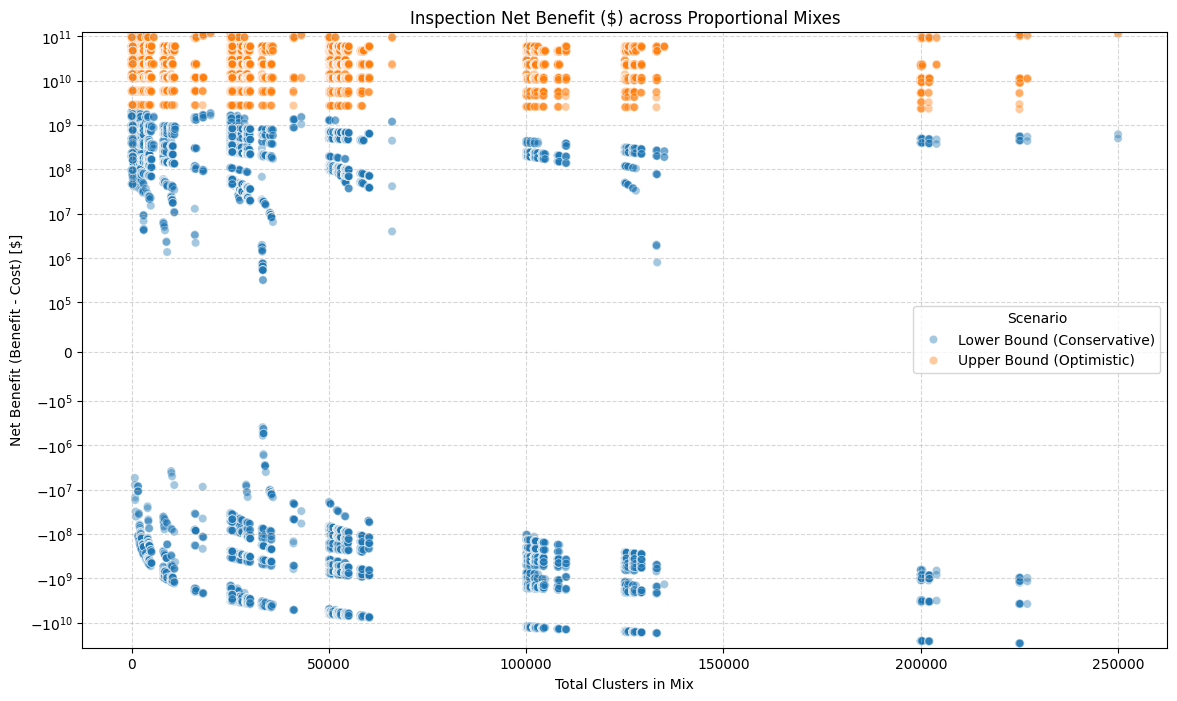

In [ ]:
plt.figure(figsize=(14, 8))

# Using the updated efficiency_long_df with Net Benefit metrics
sns.scatterplot(
    data=efficiency_long_df,
    x='Total Clusters in Mix',
    y='Net Benefit ($)',
    hue='Benefit Scenario',
    alpha=0.4
)

plt.title('Inspection Net Benefit ($) across Proportional Mixes')
plt.xlabel('Total Clusters in Mix')
plt.ylabel('Net Benefit (Benefit - Cost) [$]')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title='Scenario')
# Using symlog because Net Benefit can be negative (losses) or zero
plt.yscale('symlog', linthresh=1e5)
plt.show()

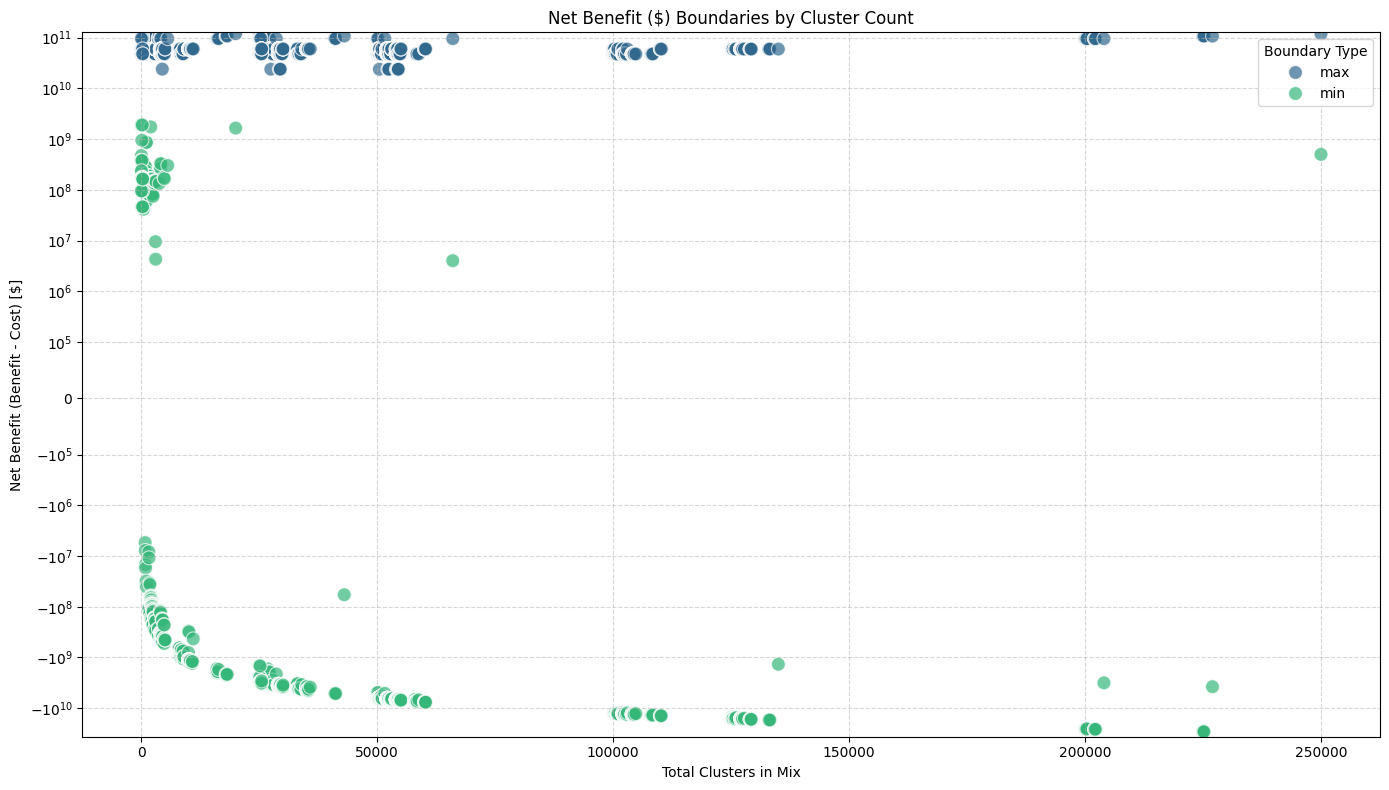

In [ ]:
plt.figure(figsize=(14, 8))

# Aggregate using efficiency_long_df to find the absolute min and max Net Benefit per cluster count
agg_net_benefit = efficiency_long_df.groupby(['Mix ID', 'Total Clusters in Mix'])['Net Benefit ($)'].agg(['min', 'max']).reset_index()

# Pivot min and max into a single column for plotting
boundary_plot_df = agg_net_benefit.melt(
    id_vars=['Total Clusters in Mix'],
    value_vars=['max', 'min'],
    var_name='Net Benefit Boundary',
    value_name='Net Benefit ($)'
)

# Create the scatter plot focusing on Net Benefit boundaries
sns.scatterplot(
    data=boundary_plot_df,
    x='Total Clusters in Mix',
    y='Net Benefit ($)',
    hue='Net Benefit Boundary',
    palette='viridis',
    alpha=0.7,
    s=100
)

plt.title('Net Benefit ($) Boundaries by Cluster Count')
plt.xlabel('Total Clusters in Mix')
plt.ylabel('Net Benefit (Benefit - Cost) [$]')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
# Using symlog because Net Benefit can be negative or zero
plt.yscale('symlog', linthresh=1e5)
plt.legend(title='Boundary Type')
plt.tight_layout()
plt.show()